# 6.3.1 最终模型测试集性能评估

本 Notebook 读取 **6.2.4 已确定的最终模型**，对完全隔离的测试集执行一次正式评估。  
已兼容当前服务器目录 `/root/autodl-tmp/课设`、中英文选择结果字段、静态图片输出和测试结果复用机制。

In [1]:
# ==========================================
# Cell 2：环境、项目路径、字体与测试评估锁
# ==========================================
import os
import sys
import json
import time
import hashlib
import random
import warnings
from pathlib import Path
from datetime import datetime

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties
from IPython.display import display, Image as IPythonImage

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet18

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from tqdm import tqdm

# ------------------------------
# 自动定位项目根目录
# ------------------------------
PROJECT_ROOT_CANDIDATES = [
    Path("/root/autodl-tmp/课设"),
    Path("/root/autodl-tmp/.autodl/课设"),
]
PROJECT_ROOT = next(
    (path for path in PROJECT_ROOT_CANDIDATES if path.is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "未找到课设项目根目录。已检查：\n"
        + "\n".join(str(path) for path in PROJECT_ROOT_CANDIDATES)
    )

RESULTS_ROOT = PROJECT_ROOT / "results"
MODELS_ROOT = PROJECT_ROOT / "models"
SPLIT_DIR = RESULTS_ROOT / "4.3.1_数据集分层划分"
TEST_MANIFEST_PATH = SPLIT_DIR / "05_测试集样本清单.csv"
SELECTION_DIR = (
    RESULTS_ROOT / "06_模型训练与优化"
    / "6.2.4_候选模型训练结果对比与最终模型确定"
)
SELECTION_JSON_PATH = SELECTION_DIR / "00_最终模型选择结果.json"
OUTPUT_DIR = (
    RESULTS_ROOT / "06_模型训练与优化"
    / "6.3.1_最终模型测试集性能评估"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORCE_REEVALUATE_TEST = False
TEST_STATE_PATH = OUTPUT_DIR / "00_测试集正式评估状态.json"

SEED = 42
IMAGE_SIZE = 224
NUM_CLASSES = 10
BATCH_SIZE = 64
NUM_WORKERS = min(8, os.cpu_count() or 1)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

CLASS_NAMES_EN = [
    "AnnualCrop", "PermanentCrop", "Forest", "HerbaceousVegetation",
    "Pasture", "Highway", "Industrial", "Residential", "River", "SeaLake",
]
CLASS_NAMES_CN = [
    "年生作物地", "永久性作物地", "森林", "草本植被", "牧场",
    "高速公路", "工业区", "居民区", "河流", "海洋与湖泊",
]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES_EN)}
CLASS_CN_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES_CN)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------
# 中文字体：找到则使用，找不到只警告，不中断
# ------------------------------
def configure_chinese_font():
    candidates = [
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc"),
        Path("/usr/share/fonts/truetype/wqy/wqy-microhei.ttc"),
        Path("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"),
    ]
    font_path = next((path for path in candidates if path.is_file()), None)
    if font_path is None:
        warnings.warn("未找到中文字体，图中中文可能显示异常。")
        return None
    font_manager.fontManager.addfont(str(font_path))
    font_name = FontProperties(fname=str(font_path)).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name]
    return font_path

CHINESE_FONT_PATH = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

def read_csv_flexible(path, **kwargs):
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "gb18030", "gbk"):
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError as error:
            last_error = error
    raise RuntimeError(f"无法读取CSV编码：{path}\n最后错误：{last_error}")

print("=" * 76)
print("6.3.1 最终模型测试集性能评估：环境检查")
print("=" * 76)
print(f"项目根目录：{PROJECT_ROOT}")
print(f"运行设备：{DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU型号：{torch.cuda.get_device_name(0)}")
print(f"批次大小：{BATCH_SIZE}")
print(f"DataLoader进程数：{NUM_WORKERS}")
print(f"混合精度：{USE_AMP}")
print(f"输出目录：{OUTPUT_DIR}")


6.3.1 最终模型测试集性能评估：环境检查
项目根目录：/root/autodl-tmp/课设
运行设备：cuda:0
GPU型号：NVIDIA GeForce RTX 4090 D
批次大小：64
DataLoader进程数：8
混合精度：True
输出目录：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.1_最终模型测试集性能评估


In [2]:
# ==========================================
# Cell 3：兼容读取最终模型选择结果
# ==========================================
if not SELECTION_JSON_PATH.is_file():
    raise FileNotFoundError(
        "没有找到6.2.4生成的最终模型选择结果：\n"
        f"{SELECTION_JSON_PATH}"
    )

selection_result = json.loads(
    SELECTION_JSON_PATH.read_text(encoding="utf-8")
)

def get_first(mapping, keys, default=None):
    for key in keys:
        if key in mapping and mapping[key] not in (None, ""):
            return mapping[key]
    return default

def normalize_ratio(value):
    if value in (None, ""):
        return np.nan
    number = float(value)
    if 1 < number <= 100:
        number /= 100.0
    return number

SELECTED_MODEL_NAME = str(get_first(
    selection_result,
    ["最终模型名称", "selected_model_name", "模型名称", "final_model_name"],
    "",
)).strip()

checkpoint_text = get_first(
    selection_result,
    ["最终模型权重", "final_checkpoint", "最终权重", "checkpoint_path"],
    "",
)

validation_macro_f1 = normalize_ratio(get_first(
    selection_result,
    ["验证Macro-F1", "selected_validation_macro_f1", "Macro-F1", "validation_macro_f1"],
    np.nan,
))
validation_top1 = normalize_ratio(get_first(
    selection_result,
    ["验证Top-1", "selected_validation_top1", "Top-1", "validation_top1"],
    np.nan,
))
validation_top3 = normalize_ratio(get_first(
    selection_result,
    ["验证Top-3", "selected_validation_top3", "Top-3", "validation_top3"],
    np.nan,
))
selected_total_parameters = get_first(
    selection_result,
    ["模型总参数", "selected_total_parameters", "总参数量"],
    np.nan,
)

def infer_model_type(model_name, checkpoint_path_text=""):
    text = f"{model_name} {checkpoint_path_text}".lower()
    if "resnet18" in text or "resnet" in text:
        return "resnet18_transfer"
    if "baseline" in text or "cnn" in text:
        return "baseline_cnn"
    return ""

SELECTED_MODEL_TYPE = str(get_first(
    selection_result,
    ["selected_model_type", "最终模型类型", "model_type"],
    "",
)).strip().lower()

if not SELECTED_MODEL_TYPE:
    SELECTED_MODEL_TYPE = infer_model_type(SELECTED_MODEL_NAME, checkpoint_text)

if SELECTED_MODEL_TYPE not in {"baseline_cnn", "resnet18_transfer"}:
    raise ValueError(
        "无法识别最终模型类型。"
        f"\n模型名称：{SELECTED_MODEL_NAME}"
        f"\n选择结果字段：{list(selection_result.keys())}"
    )

# ------------------------------
# 兼容选择结果中的旧路径，并在models目录中自动回退
# ------------------------------
checkpoint_candidates = []
if checkpoint_text:
    raw_checkpoint = Path(str(checkpoint_text))
    checkpoint_candidates.append(raw_checkpoint)
    checkpoint_candidates.append(MODELS_ROOT / raw_checkpoint.name)

if SELECTED_MODEL_TYPE == "resnet18_transfer":
    checkpoint_candidates += [
        MODELS_ROOT / "resnet18_transfer" / "resnet18_transfer_best_model.pth",
        MODELS_ROOT / "resnet18_transfer" / "resnet18_transfer_phase_C_best.pth",
        MODELS_ROOT / "final_model" / "final_model_best.pth",
    ]
else:
    checkpoint_candidates += [
        MODELS_ROOT / "baseline_cnn" / "baseline_cnn_best_model.pth",
        MODELS_ROOT / "baseline_cnn" / "BaselineCNN_best_model.pth",
        MODELS_ROOT / "final_model" / "final_model_best.pth",
    ]

FINAL_CHECKPOINT_PATH = next(
    (path for path in checkpoint_candidates if path.is_file()),
    None,
)

if FINAL_CHECKPOINT_PATH is None:
    model_keyword = "resnet18" if SELECTED_MODEL_TYPE == "resnet18_transfer" else "baseline"
    searched = [
        path for path in MODELS_ROOT.rglob("*.pth")
        if model_keyword in str(path).lower() and "best" in path.name.lower()
    ]
    if searched:
        searched.sort(key=lambda path: path.stat().st_mtime, reverse=True)
        FINAL_CHECKPOINT_PATH = searched[0]

if FINAL_CHECKPOINT_PATH is None or not FINAL_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "未找到最终模型权重。已检查：\n"
        + "\n".join(str(path) for path in checkpoint_candidates)
    )

FINAL_CHECKPOINT_PATH = FINAL_CHECKPOINT_PATH.resolve()
FINAL_CHECKPOINT_SHA256 = sha256_file(FINAL_CHECKPOINT_PATH)

selection_df = pd.DataFrame([{
    "最终模型": SELECTED_MODEL_NAME,
    "模型类型": SELECTED_MODEL_TYPE,
    "验证Macro-F1": validation_macro_f1,
    "验证Top-1": validation_top1,
    "验证Top-3": validation_top3,
    "模型参数量": selected_total_parameters,
    "最终权重": str(FINAL_CHECKPOINT_PATH),
    "权重SHA256": FINAL_CHECKPOINT_SHA256,
}])
display(selection_df)

print("最终模型选择结果读取成功。")
print("本Notebook只进行一次测试集评估，不会重新选择或训练模型。")


,最终模型,模型类型,验证Macro-F1,验证Top-1,验证Top-3,模型参数量,最终权重,权重SHA256
0,ResNet18Transfer,resnet18_transfer,0.98256,0.98321,0.999753,11181642,/root/autodl-tmp/课设/models/resnet18_transfer/r...,d7160b76453119f640d382337feb293a892df7a3ad62a1...


最终模型选择结果读取成功。
本Notebook只进行一次测试集评估，不会重新选择或训练模型。


In [3]:
# ==========================================
# Cell 4：读取、修复并验证测试集清单
# ==========================================
def detect_column(dataframe, candidates):
    normalized = {
        str(column).replace("\ufeff", "").strip(): column
        for column in dataframe.columns
    }
    for name in candidates:
        if name in normalized:
            return normalized[name]
    return None

def resolve_image_path(raw_path, class_name=None):
    text = str(raw_path).strip().replace("\\", "/")
    raw = Path(text)
    candidates = []

    if raw.is_absolute():
        candidates.append(raw)

    candidates.extend([
        PROJECT_ROOT / text,
        PROJECT_ROOT / "EuroSAT_RGB" / text,
        PROJECT_ROOT / "EuroSAT_RGB" / "data" / text,
    ])

    lower = text.lower()
    for marker in ("eurosat_rgb/", "data/"):
        if marker in lower:
            index = lower.index(marker)
            suffix = text[index:]
            candidates.append(PROJECT_ROOT / suffix)
            if marker == "data/":
                candidates.append(PROJECT_ROOT / "EuroSAT_RGB" / suffix)

    filename = Path(text).name
    if class_name:
        candidates.extend([
            PROJECT_ROOT / "EuroSAT_RGB" / "data" / str(class_name) / filename,
            PROJECT_ROOT / "EuroSAT_RGB" / "2750" / str(class_name) / filename,
            PROJECT_ROOT / "EuroSAT_RGB" / str(class_name) / filename,
        ])

    seen = []
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate not in seen:
            seen.append(candidate)

    for candidate in seen:
        if candidate.is_file():
            return str(candidate.resolve())

    return str(seen[0] if seen else raw)

if not TEST_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"测试集清单不存在：{TEST_MANIFEST_PATH}")

raw_df = read_csv_flexible(TEST_MANIFEST_PATH, low_memory=False)
raw_df.columns = [
    str(column).replace("\ufeff", "").strip()
    for column in raw_df.columns
]

path_col = detect_column(raw_df, [
    "完整图像路径", "相对路径", "图像路径", "文件路径",
    "绝对路径", "路径", "image_path", "file_path", "filepath", "path",
])
class_en_col = detect_column(raw_df, [
    "类别英文名称", "英文类别名称", "class_name", "class",
])
class_cn_col = detect_column(raw_df, [
    "类别中文名称", "中文类别名称",
])
label_col = detect_column(raw_df, [
    "类别索引", "类别编号", "标签索引", "标签编号", "标签",
    "class_index", "label", "target",
])

if path_col is None:
    raise KeyError(f"测试清单没有可识别的路径字段。实际字段：{raw_df.columns.tolist()}")

test_df = pd.DataFrame({
    "原始路径": raw_df[path_col].astype(str).str.strip(),
})

if class_en_col is not None:
    test_df["类别英文名称"] = raw_df[class_en_col].astype(str).str.strip()
    mapped = test_df["类别英文名称"].map(CLASS_TO_INDEX)
    if mapped.notna().all():
        test_df["类别索引"] = mapped.astype(int)

if "类别索引" not in test_df.columns and class_cn_col is not None:
    test_df["类别中文名称"] = raw_df[class_cn_col].astype(str).str.strip()
    mapped = test_df["类别中文名称"].map(CLASS_CN_TO_INDEX)
    if mapped.notna().all():
        test_df["类别索引"] = mapped.astype(int)

if "类别索引" not in test_df.columns and label_col is not None:
    labels = pd.to_numeric(raw_df[label_col], errors="raise").astype(int)
    if set(labels.unique()) == set(range(1, 11)):
        labels = labels - 1
    test_df["类别索引"] = labels

if "类别索引" not in test_df.columns:
    raise KeyError("测试清单没有可识别的类别标签。")

if not test_df["类别索引"].between(0, NUM_CLASSES - 1).all():
    raise ValueError("测试清单类别索引不在0—9范围内。")

if "类别英文名称" not in test_df.columns:
    test_df["类别英文名称"] = test_df["类别索引"].map(dict(enumerate(CLASS_NAMES_EN)))
if "类别中文名称" not in test_df.columns:
    test_df["类别中文名称"] = test_df["类别索引"].map(dict(enumerate(CLASS_NAMES_CN)))

test_df["完整图像路径"] = [
    resolve_image_path(path, class_name)
    for path, class_name in zip(
        test_df["原始路径"],
        test_df["类别英文名称"],
    )
]

if len(test_df) != 4050:
    raise ValueError(f"测试集应为4,050张，实际读取到{len(test_df):,}张。")
if set(test_df["类别索引"].unique()) != set(range(NUM_CLASSES)):
    raise ValueError("测试集没有覆盖完整的10个类别。")
if test_df["完整图像路径"].duplicated().any():
    raise ValueError("测试集清单存在重复图像路径。")

missing_mask = ~test_df["完整图像路径"].map(lambda path: Path(path).is_file())
if missing_mask.any():
    missing_examples = test_df.loc[missing_mask, ["原始路径", "完整图像路径"]].head(10)
    display(missing_examples)
    raise FileNotFoundError(
        f"测试集存在{int(missing_mask.sum())}张缺失图像，示例已显示。"
    )

class_count_df = (
    test_df.groupby(["类别索引", "类别中文名称"], as_index=False)
    .size()
    .rename(columns={"size": "测试集数量"})
)
display(class_count_df)

standard_manifest_path = OUTPUT_DIR / "01_测试集标准化清单.csv"
test_df.to_csv(standard_manifest_path, index=False, encoding="utf-8-sig")
print(f"测试集清单检查通过：{len(test_df):,}张。")
print(f"标准化清单已保存：{standard_manifest_path}")


,类别索引,类别中文名称,测试集数量
0,0,年生作物地,450
1,1,永久性作物地,375
2,2,森林,450
3,3,草本植被,450
4,4,牧场,300
5,5,高速公路,375
6,6,工业区,375
7,7,居民区,450
8,8,河流,375
9,9,海洋与湖泊,450


测试集清单检查通过：4,050张。
标准化清单已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.1_最终模型测试集性能评估/01_测试集标准化清单.csv


In [4]:
# ==========================================
# Cell 5：构建测试DataLoader并加载最终模型
# ==========================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ManifestDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        with Image.open(row["完整图像路径"]) as file:
            image = file.convert("RGB")
        return (
            self.transform(image),
            int(row["类别索引"]),
            row["完整图像路径"],
        )

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=True
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, tensor):
        return self.pool(self.relu(self.bn(self.conv(tensor))))

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.50)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, tensor):
        tensor = self.block1(tensor)
        tensor = self.block2(tensor)
        tensor = self.block3(tensor)
        tensor = self.block4(tensor)
        tensor = self.global_pool(tensor)
        tensor = torch.flatten(tensor, 1)
        tensor = self.dropout(tensor)
        return self.classifier(tensor)

def load_checkpoint_state(path):
    payload = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(payload, dict) and "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
    elif isinstance(payload, dict) and all(torch.is_tensor(value) for value in payload.values()):
        state_dict = payload
        payload = {"model_state_dict": state_dict}
    else:
        raise ValueError(f"无法识别权重格式：{path}")

    # 兼容DataParallel产生的module.前缀
    if state_dict and all(str(key).startswith("module.") for key in state_dict):
        state_dict = {
            str(key)[7:]: value
            for key, value in state_dict.items()
        }
    return state_dict, payload

state_dict, checkpoint_payload = load_checkpoint_state(FINAL_CHECKPOINT_PATH)

def build_selected_model(model_type, state_dict):
    if model_type == "baseline_cnn":
        return BaselineCNN(NUM_CLASSES)

    if model_type == "resnet18_transfer":
        model = resnet18(weights=None)
        if "fc.1.weight" in state_dict:
            model.fc = nn.Sequential(
                nn.Dropout(p=0.30),
                nn.Linear(model.fc.in_features, NUM_CLASSES),
            )
        elif "fc.weight" in state_dict:
            model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
        else:
            raise KeyError(
                "ResNet18权重中未找到fc.1.weight或fc.weight，"
                "无法判断分类头结构。"
            )
        return model

    raise ValueError(f"未知模型类型：{model_type}")

model = build_selected_model(SELECTED_MODEL_TYPE, state_dict)
load_result = model.load_state_dict(state_dict, strict=True)
if load_result.missing_keys or load_result.unexpected_keys:
    raise RuntimeError(
        f"权重加载不完整。missing={load_result.missing_keys}, "
        f"unexpected={load_result.unexpected_keys}"
    )

model = model.to(DEVICE)
model.eval()

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_kwargs = dict(
    dataset=ManifestDataset(test_df, test_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    worker_init_fn=seed_worker,
    generator=torch.Generator().manual_seed(SEED),
    drop_last=False,
)
if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=True,
        prefetch_factor=2,
    )

test_loader = DataLoader(**loader_kwargs)
test_dataset = test_loader.dataset

with torch.inference_mode():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    output = model(dummy)

if tuple(output.shape) != (2, NUM_CLASSES):
    raise RuntimeError(f"模型输出形状异常：{tuple(output.shape)}")

print(f"最终模型：{SELECTED_MODEL_NAME}")
print(f"模型类型：{SELECTED_MODEL_TYPE}")
print(f"测试集样本：{len(test_dataset):,}")
print(f"测试批次数：{len(test_loader)}")
print(f"前向输出形状：{tuple(output.shape)}")


最终模型：ResNet18Transfer
模型类型：resnet18_transfer
测试集样本：4,050
测试批次数：64
前向输出形状：(2, 10)


In [5]:
# ==========================================
# Cell 6：执行或复用测试集正式评估
# ==========================================
PREDICTION_PATH = OUTPUT_DIR / "02_测试集预测明细.csv"
METRIC_PATH = OUTPUT_DIR / "03_测试集总体指标.csv"

def evaluate_test():
    criterion = nn.CrossEntropyLoss()
    running_loss = 0.0
    sample_count = 0
    top1_correct = 0
    top3_correct = 0
    true_values = []
    pred_values = []
    confidences = []
    paths = []

    start = time.perf_counter()
    with torch.inference_mode():
        progress = tqdm(
            test_loader,
            desc="最终模型测试集评估",
            file=sys.stdout,
            dynamic_ncols=False,
            mininterval=1.0,
        )
        for images, labels, batch_paths in progress:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            probabilities = torch.softmax(logits.float(), dim=1)
            confidence, predictions = probabilities.max(dim=1)
            top3_indices = logits.topk(k=3, dim=1).indices

            current_batch_size = labels.size(0)
            running_loss += float(loss.item()) * current_batch_size
            sample_count += current_batch_size
            top1_correct += int(predictions.eq(labels).sum().item())
            top3_correct += int(
                top3_indices.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
            )

            true_values.extend(labels.cpu().tolist())
            pred_values.extend(predictions.cpu().tolist())
            confidences.extend(confidence.cpu().tolist())
            paths.extend(list(batch_paths))

    elapsed = time.perf_counter() - start
    y_true = np.asarray(true_values, dtype=np.int64)
    y_pred = np.asarray(pred_values, dtype=np.int64)
    confidence_values = np.asarray(confidences, dtype=np.float32)

    metrics = {
        "最终模型": SELECTED_MODEL_NAME,
        "测试集样本数量": int(sample_count),
        "测试Loss": float(running_loss / sample_count),
        "测试Top-1": float(top1_correct / sample_count),
        "测试Top-3": float(top3_correct / sample_count),
        "Macro-Precision": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "Macro-Recall": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "Macro-F1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "Weighted-F1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "平均预测置信度": float(confidence_values.mean()),
        "推理耗时_秒": float(elapsed),
        "单张平均推理毫秒": float(elapsed * 1000 / sample_count),
    }

    detail = pd.DataFrame({
        "图像路径": paths,
        "真实类别索引": y_true,
        "真实类别中文名称": [CLASS_NAMES_CN[index] for index in y_true],
        "预测类别索引": y_pred,
        "预测类别中文名称": [CLASS_NAMES_CN[index] for index in y_pred],
        "预测置信度": confidence_values,
        "是否预测正确": y_true == y_pred,
    })
    return metrics, detail

existing_state = None
if TEST_STATE_PATH.is_file():
    try:
        existing_state = json.loads(TEST_STATE_PATH.read_text(encoding="utf-8"))
    except Exception as error:
        warnings.warn(f"已有测试状态文件无法读取，将重新评估：{error}")

can_reuse = (
    existing_state is not None
    and existing_state.get("evaluation_completed") is True
    and existing_state.get("checkpoint_sha256") == FINAL_CHECKPOINT_SHA256
    and PREDICTION_PATH.is_file()
    and METRIC_PATH.is_file()
    and not FORCE_REEVALUATE_TEST
)

if can_reuse:
    print("检测到同一最终模型的完整测试结果，本次直接复用，不重复推理。")
    test_metrics = read_csv_flexible(METRIC_PATH).iloc[0].to_dict()
    prediction_df = read_csv_flexible(PREDICTION_PATH, low_memory=False)
else:
    if (
        existing_state
        and existing_state.get("checkpoint_sha256") not in (None, FINAL_CHECKPOINT_SHA256)
        and not FORCE_REEVALUATE_TEST
    ):
        raise RuntimeError(
            "测试目录中已有另一份模型的测试记录。"
            "确认需要覆盖时，请把FORCE_REEVALUATE_TEST改为True。"
        )

    test_metrics, prediction_df = evaluate_test()
    pd.DataFrame([test_metrics]).to_csv(
        METRIC_PATH, index=False, encoding="utf-8-sig"
    )
    prediction_df.to_csv(
        PREDICTION_PATH, index=False, encoding="utf-8-sig"
    )

    state = {
        "evaluation_completed": True,
        "selected_model_name": SELECTED_MODEL_NAME,
        "selected_model_type": SELECTED_MODEL_TYPE,
        "checkpoint_path": str(FINAL_CHECKPOINT_PATH),
        "checkpoint_sha256": FINAL_CHECKPOINT_SHA256,
        "test_sample_count": int(len(prediction_df)),
        "evaluated_at": datetime.now().isoformat(timespec="seconds"),
        "force_reevaluate": FORCE_REEVALUATE_TEST,
        "note": "测试集仅用于最终泛化性能报告，不用于调参。",
    }
    TEST_STATE_PATH.write_text(
        json.dumps(state, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

if len(prediction_df) != len(test_df):
    raise ValueError(
        f"预测明细数量与测试集不一致：{len(prediction_df)} vs {len(test_df)}"
    )

display(pd.DataFrame([test_metrics]))
print("测试集正式评估完成。")


最终模型测试集评估: 100%|██████████| 64/64 [00:03<00:00, 20.17it/s]


,最终模型,测试集样本数量,测试Loss,测试Top-1,测试Top-3,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1,平均预测置信度,推理耗时_秒,单张平均推理毫秒
0,ResNet18Transfer,4050,0.082841,0.98321,0.999753,0.982613,0.982844,0.982703,0.983209,0.994664,3.179763,0.785127


测试集正式评估完成。


,类别索引,类别中文名称,类别英文名称,Precision,Recall,F1,Support
0,0,年生作物地,AnnualCrop,0.975771,0.984444,0.980088,450
1,1,永久性作物地,PermanentCrop,0.965333,0.965333,0.965333,375
2,2,森林,Forest,0.988938,0.993333,0.991131,450
3,3,草本植被,HerbaceousVegetation,0.981900,0.964444,0.973094,450
4,4,牧场,Pasture,0.976744,0.980000,0.978369,300
5,5,高速公路,Highway,0.966057,0.986667,0.976253,375
6,6,工业区,Industrial,0.989333,0.989333,0.989333,375
7,7,居民区,Residential,0.995526,0.988889,0.992196,450
8,8,河流,River,0.986523,0.976000,0.981233,375
9,9,海洋与湖泊,SeaLake,1.000000,1.000000,1.000000,450


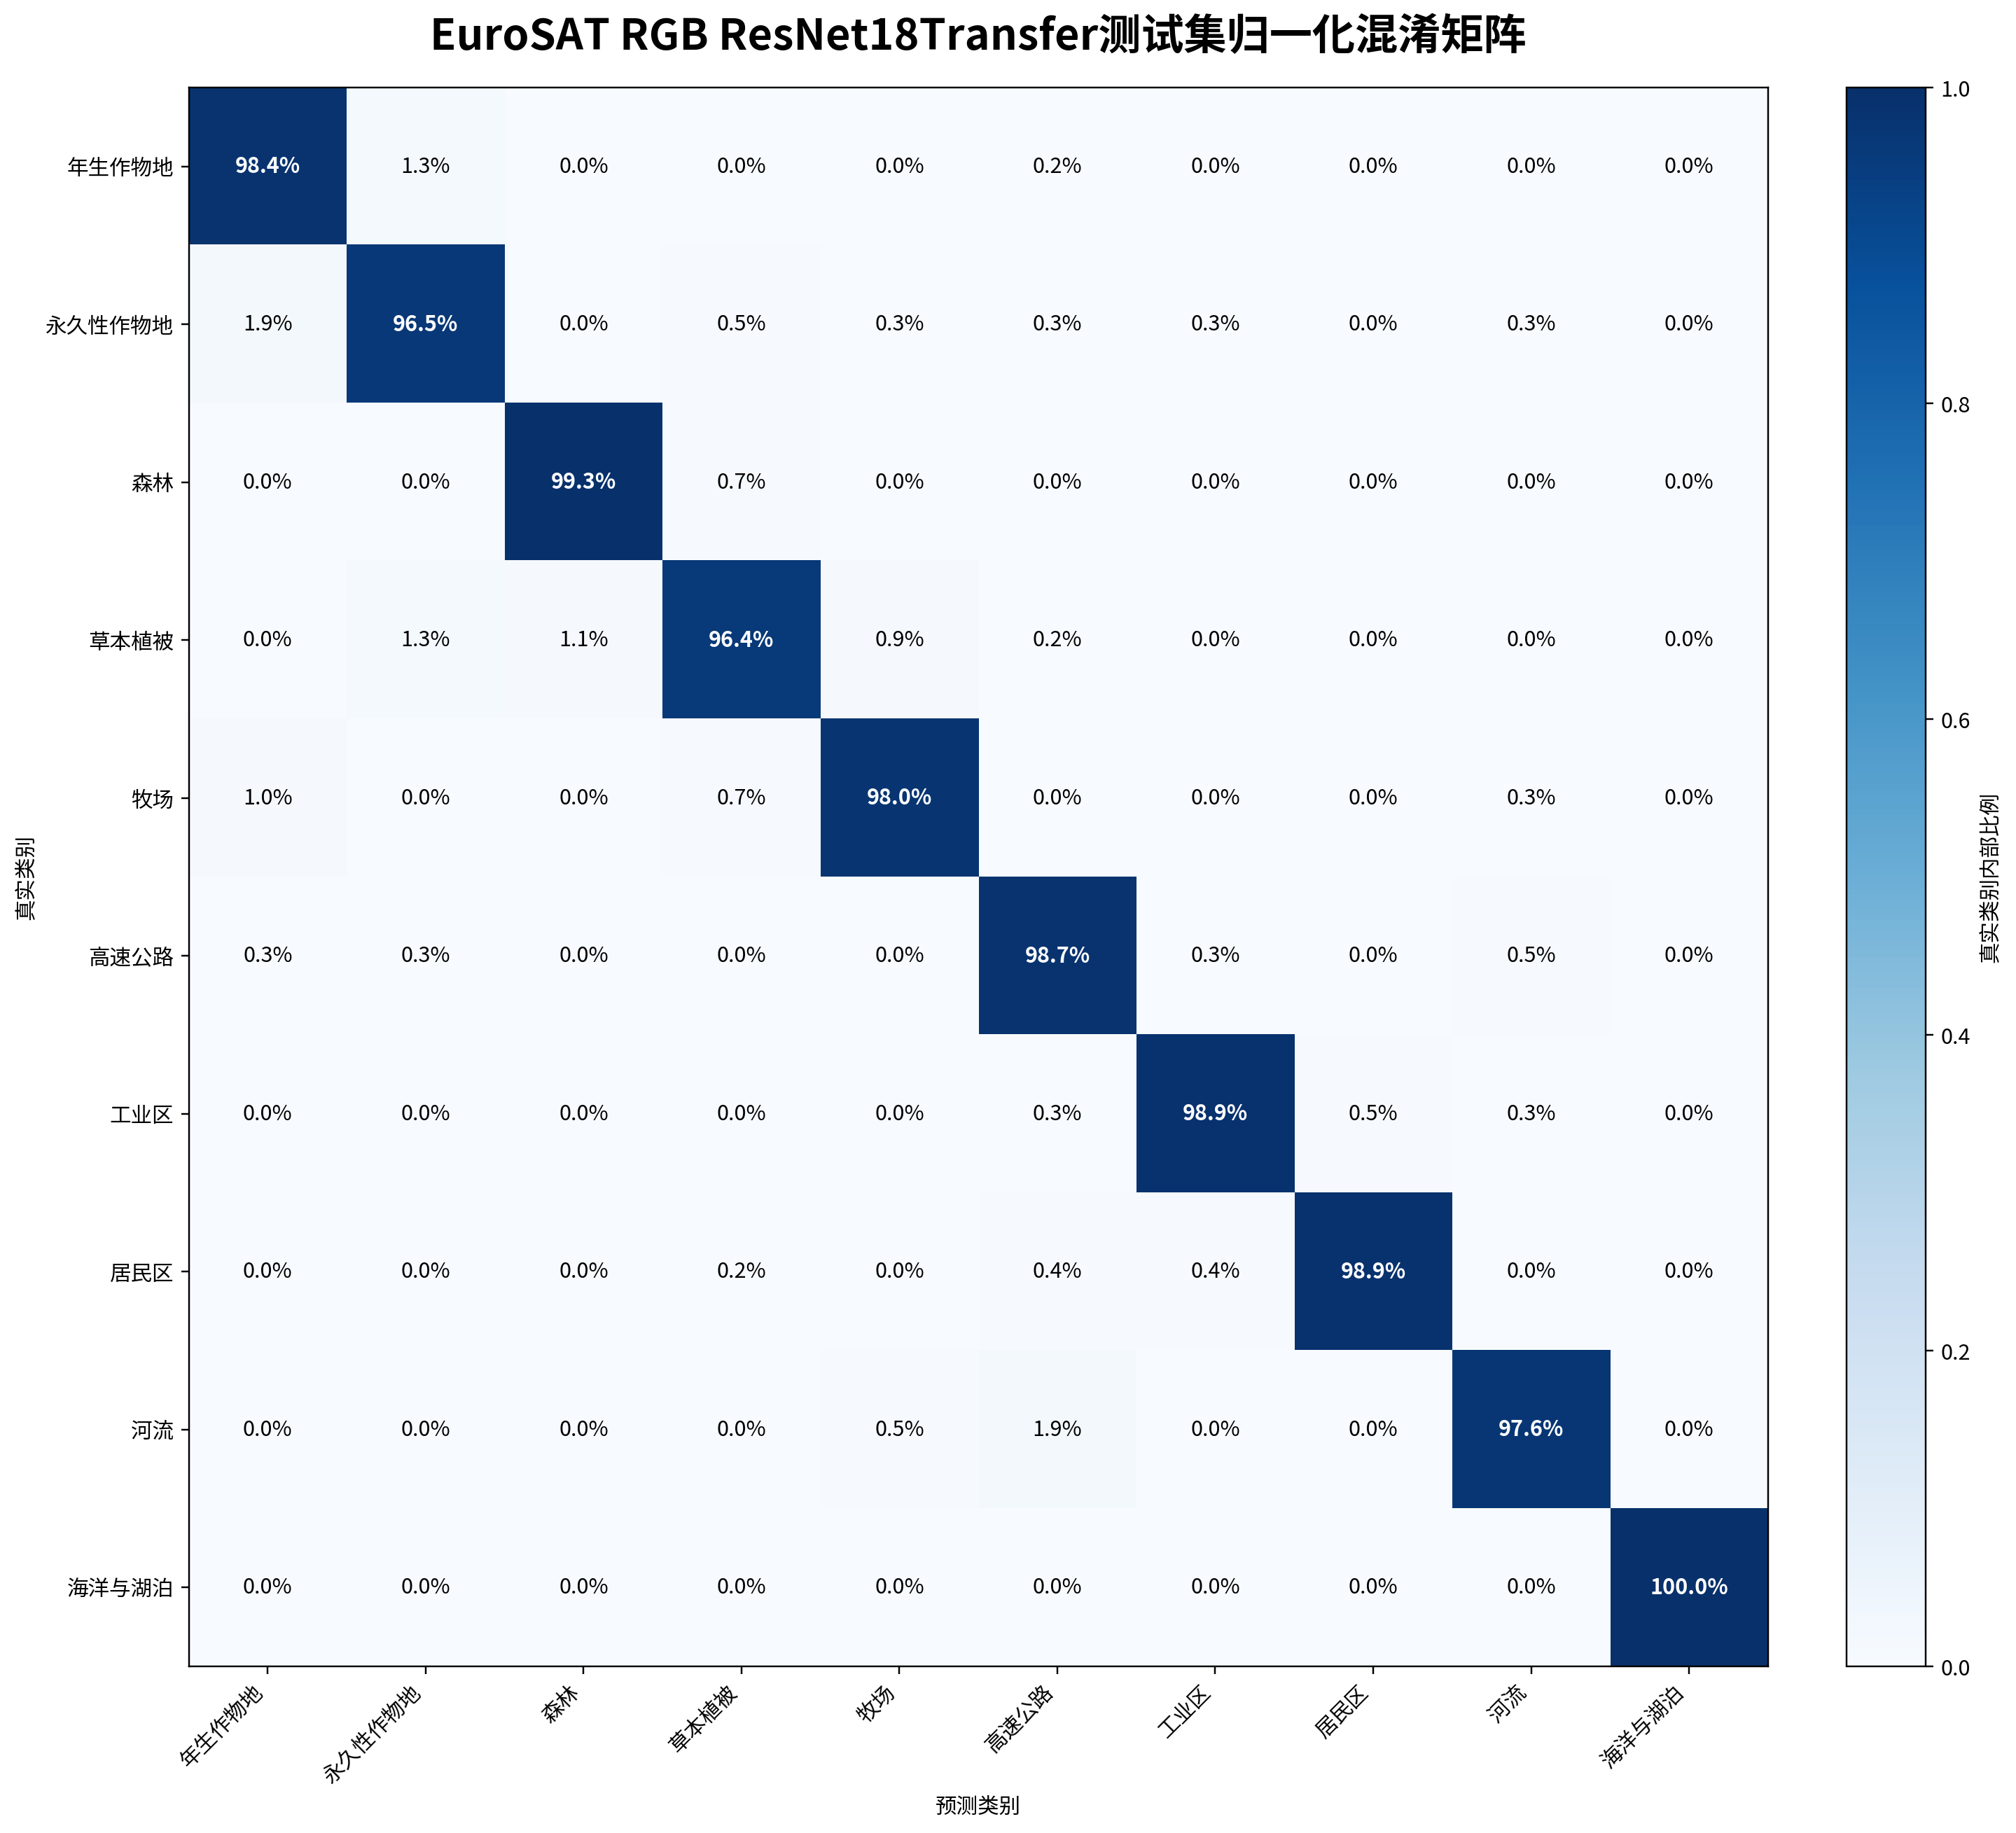

混淆矩阵已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.1_最终模型测试集性能评估/07_测试集归一化混淆矩阵.png


In [6]:
# ==========================================
# Cell 7：各类别指标与测试集混淆矩阵
# ==========================================
y_true = pd.to_numeric(
    prediction_df["真实类别索引"], errors="raise"
).to_numpy(dtype=np.int64)
y_pred = pd.to_numeric(
    prediction_df["预测类别索引"], errors="raise"
).to_numpy(dtype=np.int64)

precision, recall, f1_values, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    zero_division=0,
)

per_class_df = pd.DataFrame({
    "类别索引": range(NUM_CLASSES),
    "类别中文名称": CLASS_NAMES_CN,
    "类别英文名称": CLASS_NAMES_EN,
    "Precision": precision,
    "Recall": recall,
    "F1": f1_values,
    "Support": support.astype(int),
})
display(per_class_df)
per_class_df.to_csv(
    OUTPUT_DIR / "04_测试集各类别指标.csv",
    index=False,
    encoding="utf-8-sig",
)

cm_raw = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm_raw,
    row_sums,
    out=np.zeros_like(cm_raw, dtype=np.float64),
    where=row_sums != 0,
)

pd.DataFrame(cm_raw, index=CLASS_NAMES_CN, columns=CLASS_NAMES_CN).to_csv(
    OUTPUT_DIR / "05_测试集原始混淆矩阵.csv",
    encoding="utf-8-sig",
)
pd.DataFrame(cm_norm, index=CLASS_NAMES_CN, columns=CLASS_NAMES_CN).to_csv(
    OUTPUT_DIR / "06_测试集归一化混淆矩阵.csv",
    encoding="utf-8-sig",
)

plt.close("all")
figure, axis = plt.subplots(figsize=(14, 12))
image = axis.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
colorbar = figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
colorbar.set_label("真实类别内部比例")

axis.set_xticks(range(NUM_CLASSES))
axis.set_yticks(range(NUM_CLASSES))
axis.set_xticklabels(CLASS_NAMES_CN, rotation=45, ha="right")
axis.set_yticklabels(CLASS_NAMES_CN)
axis.set_xlabel("预测类别")
axis.set_ylabel("真实类别")
axis.set_title(
    f"EuroSAT RGB {SELECTED_MODEL_NAME}测试集归一化混淆矩阵",
    fontsize=20,
    fontweight="bold",
    pad=18,
)

for row_index in range(NUM_CLASSES):
    for column_index in range(NUM_CLASSES):
        value = cm_norm[row_index, column_index]
        axis.text(
            column_index,
            row_index,
            f"{value:.1%}",
            ha="center",
            va="center",
            color="white" if value >= 0.55 else "black",
            fontweight="bold" if row_index == column_index else "normal",
            fontsize=10,
        )

figure.tight_layout()
CM_FIGURE_PATH = OUTPUT_DIR / "07_测试集归一化混淆矩阵.png"
figure.savefig(CM_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.close(figure)

display(IPythonImage(filename=str(CM_FIGURE_PATH)))
print(f"混淆矩阵已保存：{CM_FIGURE_PATH}")


,数据子集,Top-1,Top-3,Macro-F1,相对验证集Top-1变化,相对验证集Macro-F1变化
0,验证集,0.98321,0.999753,0.982560,0.0,0.000000
1,测试集,0.98321,0.999753,0.982703,0.0,0.000143


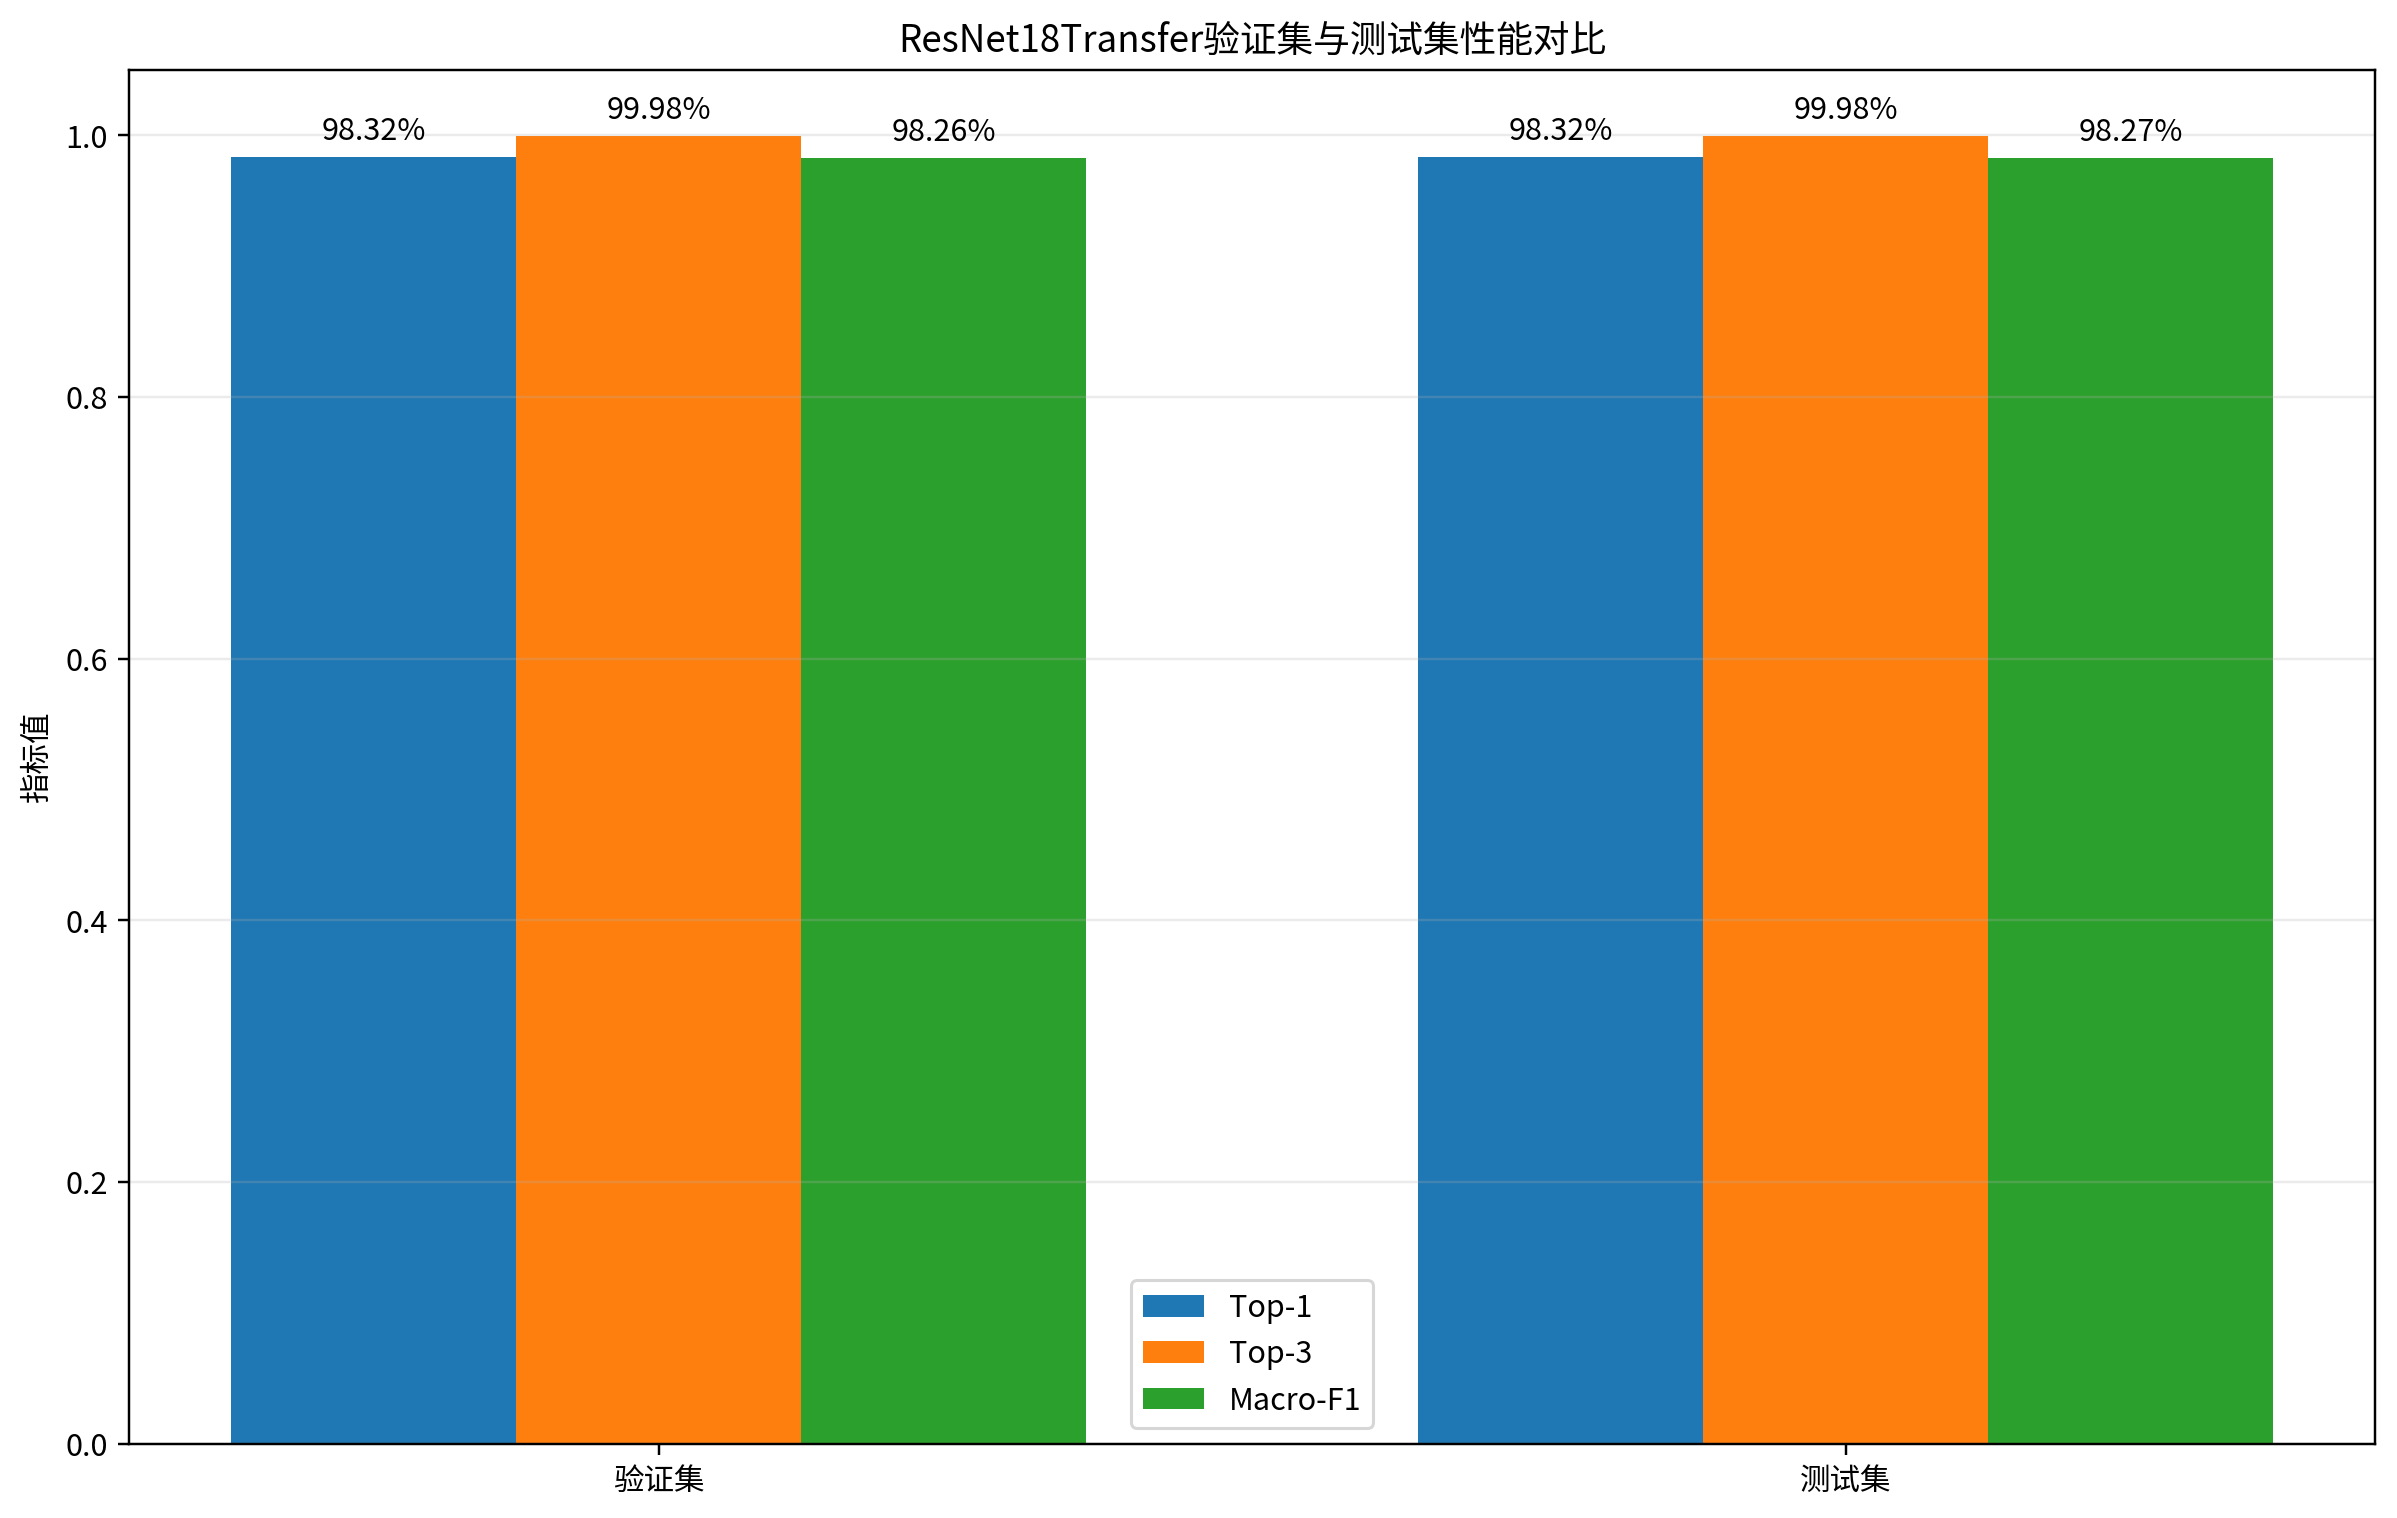

测试Top-1相对验证集变化：+0.0000%
测试Macro-F1相对验证集变化：+0.0143%


In [7]:
# ==========================================
# Cell 8：验证集与测试集泛化差距分析
# ==========================================
test_top1 = float(test_metrics["测试Top-1"])
test_top3 = float(test_metrics["测试Top-3"])
test_macro_f1 = float(test_metrics["Macro-F1"])

generalization_df = pd.DataFrame([
    {
        "数据子集": "验证集",
        "Top-1": validation_top1,
        "Top-3": validation_top3,
        "Macro-F1": validation_macro_f1,
    },
    {
        "数据子集": "测试集",
        "Top-1": test_top1,
        "Top-3": test_top3,
        "Macro-F1": test_macro_f1,
    },
])

if np.isfinite(validation_top1):
    generalization_df["相对验证集Top-1变化"] = (
        generalization_df["Top-1"] - validation_top1
    )
else:
    generalization_df["相对验证集Top-1变化"] = np.nan

if np.isfinite(validation_macro_f1):
    generalization_df["相对验证集Macro-F1变化"] = (
        generalization_df["Macro-F1"] - validation_macro_f1
    )
else:
    generalization_df["相对验证集Macro-F1变化"] = np.nan

display(generalization_df)
generalization_df.to_csv(
    OUTPUT_DIR / "08_验证集与测试集泛化差距.csv",
    index=False,
    encoding="utf-8-sig",
)

available_metrics = [
    column for column in ["Top-1", "Top-3", "Macro-F1"]
    if pd.to_numeric(generalization_df[column], errors="coerce").notna().all()
]

positions = np.arange(2)
width = min(0.24, 0.72 / max(1, len(available_metrics)))
plt.close("all")
figure, axis = plt.subplots(figsize=(11, 7))

for metric_index, column in enumerate(available_metrics):
    values = generalization_df[column].to_numpy(dtype=float)
    offset = (metric_index - (len(available_metrics) - 1) / 2) * width
    bars = axis.bar(positions + offset, values, width=width, label=column)
    for bar, value in zip(bars, values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.008, 1.02),
            f"{value:.2%}",
            ha="center",
            va="bottom",
        )

axis.set_xticks(positions)
axis.set_xticklabels(generalization_df["数据子集"])
axis.set_ylim(0, 1.05)
axis.set_ylabel("指标值")
axis.set_title(f"{SELECTED_MODEL_NAME}验证集与测试集性能对比")
axis.grid(axis="y", alpha=0.25)
axis.legend()

figure.tight_layout()
GENERALIZATION_FIGURE_PATH = OUTPUT_DIR / "09_验证集与测试集性能对比.png"
figure.savefig(GENERALIZATION_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.close(figure)

display(IPythonImage(filename=str(GENERALIZATION_FIGURE_PATH)))

if np.isfinite(validation_top1):
    print(f"测试Top-1相对验证集变化：{test_top1 - validation_top1:+.4%}")
else:
    print("选择结果中未记录验证Top-1，已跳过Top-1差距计算。")

if np.isfinite(validation_macro_f1):
    print(
        f"测试Macro-F1相对验证集变化："
        f"{test_macro_f1 - validation_macro_f1:+.4%}"
    )
else:
    print("选择结果中未记录验证Macro-F1，已跳过Macro-F1差距计算。")


In [8]:
# ==========================================
# Cell 9：测试结果总结与输出文件清单
# ==========================================
weakest_classes = per_class_df.nsmallest(3, "F1")[
    ["类别中文名称", "F1", "Recall"]
]

validation_top1_text = (
    f"{validation_top1:.4%}" if np.isfinite(validation_top1) else "未记录"
)
validation_macro_f1_text = (
    f"{validation_macro_f1:.4%}"
    if np.isfinite(validation_macro_f1)
    else "未记录"
)
top1_change_text = (
    f"{test_top1 - validation_top1:+.4%}"
    if np.isfinite(validation_top1)
    else "无法计算"
)
macro_change_text = (
    f"{test_macro_f1 - validation_macro_f1:+.4%}"
    if np.isfinite(validation_macro_f1)
    else "无法计算"
)

summary = f"""
EuroSAT RGB最终模型测试集性能评估总结
============================================================

最终模型：{SELECTED_MODEL_NAME}
模型类型：{SELECTED_MODEL_TYPE}
测试集样本数量：{int(float(test_metrics['测试集样本数量'])):,}
测试Loss：{float(test_metrics['测试Loss']):.6f}
测试Top-1：{float(test_metrics['测试Top-1']):.4%}
测试Top-3：{float(test_metrics['测试Top-3']):.4%}
测试Macro-Precision：{float(test_metrics['Macro-Precision']):.4%}
测试Macro-Recall：{float(test_metrics['Macro-Recall']):.4%}
测试Macro-F1：{float(test_metrics['Macro-F1']):.4%}
测试Weighted-F1：{float(test_metrics['Weighted-F1']):.4%}

验证集Top-1：{validation_top1_text}
验证集Macro-F1：{validation_macro_f1_text}
Top-1泛化变化：{top1_change_text}
Macro-F1泛化变化：{macro_change_text}

测试集F1最低的三个类别：
{weakest_classes.to_string(index=False)}

说明：
1. 测试集未参与模型选择与参数调整；
2. 当前结果是最终模型的正式泛化性能；
3. 后续仅进行误分类分析和可解释性分析，不再依据测试结果调参。
""".strip()

SUMMARY_PATH = OUTPUT_DIR / "10_最终模型测试集性能评估总结.txt"
SUMMARY_PATH.write_text(summary, encoding="utf-8")

output_manifest = pd.DataFrame([
    {
        "文件名称": path.name,
        "文件路径": str(path),
        "文件大小_KB": round(path.stat().st_size / 1024, 2),
    }
    for path in sorted(OUTPUT_DIR.iterdir())
    if path.is_file()
])
OUTPUT_MANIFEST_PATH = OUTPUT_DIR / "11_本节输出文件清单.csv"
output_manifest.to_csv(
    OUTPUT_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(summary)
print(f"\n总结已保存：{SUMMARY_PATH}")
print(f"输出清单已保存：{OUTPUT_MANIFEST_PATH}")
print("\n6.3.1执行完成。下一步运行6.3.2。")


EuroSAT RGB最终模型测试集性能评估总结

最终模型：ResNet18Transfer
模型类型：resnet18_transfer
测试集样本数量：4,050
测试Loss：0.082841
测试Top-1：98.3210%
测试Top-3：99.9753%
测试Macro-Precision：98.2613%
测试Macro-Recall：98.2844%
测试Macro-F1：98.2703%
测试Weighted-F1：98.3209%

验证集Top-1：98.3210%
验证集Macro-F1：98.2560%
Top-1泛化变化：+0.0000%
Macro-F1泛化变化：+0.0143%

测试集F1最低的三个类别：
类别中文名称       F1   Recall
永久性作物地 0.965333 0.965333
  草本植被 0.973094 0.964444
  高速公路 0.976253 0.986667

说明：
1. 测试集未参与模型选择与参数调整；
2. 当前结果是最终模型的正式泛化性能；
3. 后续仅进行误分类分析和可解释性分析，不再依据测试结果调参。

总结已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.1_最终模型测试集性能评估/10_最终模型测试集性能评估总结.txt
输出清单已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.3.1_最终模型测试集性能评估/11_本节输出文件清单.csv

6.3.1执行完成。下一步运行6.3.2。
